<a href="https://colab.research.google.com/github/Surendranmengineer/suren_test/blob/master/EDA_with_Rajan_Bank_Telemarketing_case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bank Telemarketing Case Study
---
Datset URL

https://drive.google.com/file/d/1rsYRSm5SD0w4-Cb1H0XRwYvdzh9iUaHX/view?usp=sharing
<pre>
Description:  Youare Provided with Bank's Existing Customers Data.

A telemarketing Campaign was Done by the Bank Offering Various Banking Products .eg Term Deposits/FD

As an Analyst you are required to Perform EDA on Telemarketing Campaign Dta and Find Various Insights / Facts From Data.

Facts/Insights Shared by ou are to be used by the Management to increase Profits /Reven and also Reduce the Cost of Future Marketing Campaign.

In [ ]:
# Import The required libarires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

In [ ]:
inp0  = pd.read_csv('v1.csv',skiprows=2)

In [ ]:
inp0.head(3)

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no


# First Step in EDA is to do the Data Inspection
---
1. Find the Count of Rows X Cols
2. Find the Details About Column DataTypes (can u inspect if any column requires datatype correction!
3. Missing Value Inspection in Each Column( Which column is having the most missing values ) .

In [ ]:
inp0.dtypes

In [ ]:
inp0.head(2)

In [ ]:
inp0.isna().sum().sort_values(ascending=False)

,0
month,50
response,30
age,20
salary,0
customerid,0
balance,0
marital,0
default,0
housing,0
jobedu,0


# What is the Averge age of Customer in our Bank ?


In [ ]:
average_age = inp0['age'].mean()
average_age

np.float64(40.93565090394105)

In [ ]:
inp0['customerid'].head()

,customerid
0,1
1,2
2,3
3,4
4,5


Do CustomerID  play any Role in Analytics ?
---
<pre>
customerid makes sense when
-- you want to find duplicate rows(customers)
-- your data is splitted/distributed across multiple datasets , i.e. to perform joins

In [ ]:
# in our case no such use case  so we decided to drop the column.
inp0.drop('customerid',axis=1,inplace=True)

In [ ]:
inp0.head(1)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no


In [ ]:
inp0.jobedu.head()

,jobedu
0,"management,tertiary"
1,"technician,secondary"
2,"entrepreneur,secondary"
3,"blue-collar,unknown"
4,"unknown,unknown"


In [ ]:
'management,tertiary'.split(',')[0]

'management'

In [ ]:
'management,tertiary'.split(',')[1]

'tertiary'

# Feature Engineering
----
Yuu are asked to populate 2 New Columns `job` and `edu` extract data from `jobedu` field.

### Broadcasting
----

In [ ]:
inp0['job'] = inp0.jobedu.apply(lambda  line : line.split(',')[0] )

In [ ]:
inp0['job'].head()

,job
0,management
1,technician
2,entrepreneur
3,blue-collar
4,unknown


In [ ]:
inp0['edu'] = inp0.jobedu.apply(lambda  line : line.split(',')[1] )

In [ ]:
inp0[['job','edu']].head()

,job,edu
0,management,tertiary
1,technician,secondary
2,entrepreneur,secondary
3,blue-collar,unknown
4,unknown,unknown


# Let us Invesitage `job` and `edu`
----

- please share me the distinct values of `job` and `edu`

In [ ]:
inp0['job'].unique().tolist()

['management',
 'technician',
 'entrepreneur',
 'blue-collar',
 'unknown',
 'retired',
 'admin.',
 'services',
 'self-employed',
 'unemployed',
 'housemaid',
 'student']

In [ ]:
inp0['edu'].unique().tolist()

['tertiary', 'secondary', 'unknown', 'primary']

# Find the %age Distribution of Customer by their Education !
---

In [ ]:
inp0['edu'].value_counts(normalize=True) * 100

,proportion
edu,
secondary,51.319369
tertiary,29.419831
primary,15.153392
unknown,4.107407


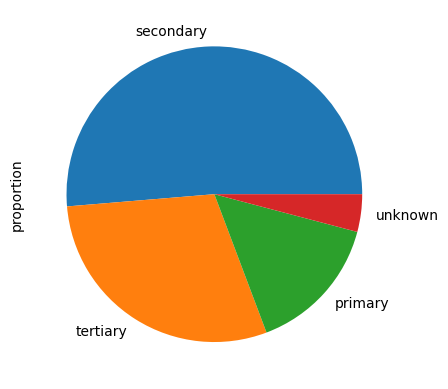

In [ ]:
inp0['edu'].value_counts(normalize=True).plot(kind='pie');

# Missing Value Identifcation & Treatment
---

Target: Age Field

- how many missing values are their in Age Column.
- wha is the %age occupancy of missing values in age column in Entire DataFrame.


In [ ]:
inp0.age.isna().sum()

np.int64(20)

In [ ]:
# finding %age occupancy

(inp0.age.isna().sum() / len(inp0)) * 100

np.float64(0.0442370219636814)

In [ ]:
# 0.04% is the missing value occupancy for Age Column in Dataframe

# - do you suggest to delete rows containing NaN
# - do you suggest to impute Nulls in Age Column.

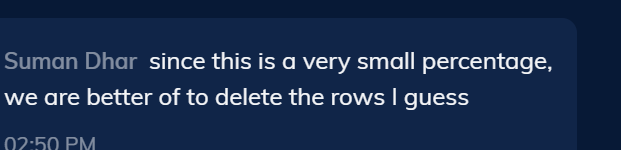

In [ ]:
# Excluding Rows Containing NaN in Age Column

In [ ]:
inp1 = inp0[ ~ inp0.age.isnull() ]

In [ ]:
inp1.age.isna().sum()

np.int64(0)